In [ ]:
!pip install -r requirements.txt

## Exercise 1 : Accident data.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import gamma

from scipy.special import gammaln
import seaborn as sns
import emcee
import corner
from dynesty import NestedSampler
import os
import tqdm

Loading the intervals

I use the Fortran-style ordering to read down columns as indicated in the dataset.

In [2]:
data = np.loadtxt('./coal_mining_accident_data.dat', comments='#')

#Reading down columns with Fortran-style ordering
intervals = data.flatten(order='F')


print(intervals.sum())
print(intervals.shape)

40549.0
(190,)


Ploting cumulative number of accidents over time.

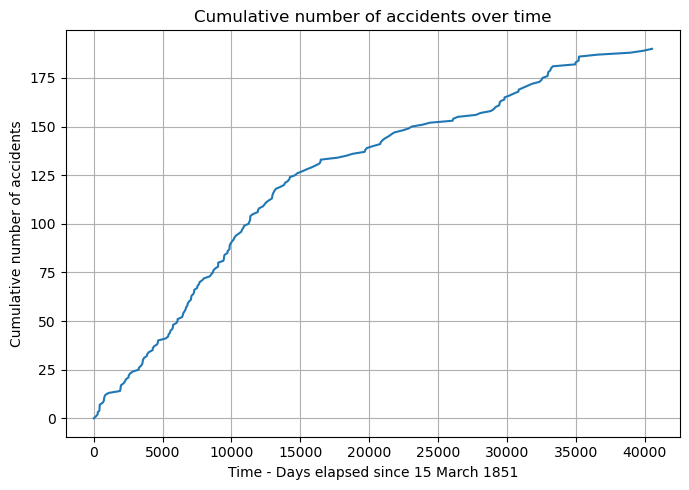

In [3]:
os.system("mkdir -p ./figs")

#Taking in account the day of the first accident which is the starting point.
cumulative_days = np.concatenate([[0], np.cumsum(intervals)])

cumulative_accidents = np.arange(len(cumulative_days))

assert len(cumulative_accidents) == 191 #To make sure I match the given value of N.

plt.figure(figsize=(7, 5))
plt.plot(cumulative_days, cumulative_accidents)
plt.xlabel('Time - Days elapsed since 15 March 1851')
plt.ylabel('Cumulative number of accidents')
plt.title('Cumulative number of accidents over time')
plt.grid(True)
plt.tight_layout()
plt.savefig('./figs/cumulative_number_of_accident_vs_time.pdf')
plt.show()
plt.close()


Mean rate of accidents over the total period covered by the data.

In [4]:
L = 40550 
N = 191 

mean_rate = N / L
print(f"Mean rate of accidents: {mean_rate:.6f} accidents/day")

Mean rate of accidents: 0.004710 accidents/day


## Exercise 2 : Priors.

(a) Illustration of the difference between plain order statistics prior and the even-numbered order statistics prior for `k = 4`.

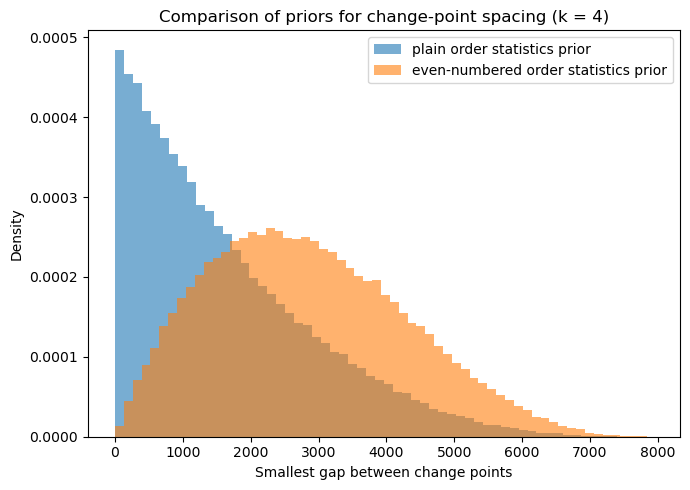

In [5]:
np.random.seed(16)

k = 4
L = 40550
N_sample = 100000 # sample size for generation of gaps

def smallest_gap_plain():
    u = np.random.uniform(0, L, k)
    u = np.sort(u)
    gaps = np.diff(np.concatenate(([0], u, [L])))
    return np.min(gaps)

def smallest_gap_even_order():
    u = np.random.uniform(0, L, 2*k +1)
    u = np.sort(u)
    s = u[1::2][:k] # even-numbered order statistics (0-indexed adjustment)
    gaps = np.diff(np.concatenate(([0], s, [L])))
    return np.min(gaps)

plain_gaps = np.array([smallest_gap_plain() for i in range(N_sample)])
even_gaps = np.array([smallest_gap_even_order() for i in range(N_sample)])

plt.figure(figsize=(7, 5))
plt.hist(plain_gaps, bins=60, density=True, alpha=0.6, label="plain order statistics prior")
plt.hist(even_gaps, bins=60, density=True, alpha=0.6, label="even-numbered order statistics prior")
plt.xlabel("Smallest gap between change points")
plt.ylabel("Density")
plt.title("Comparison of priors for change-point spacing (k = 4)")
plt.legend()
plt.tight_layout()
plt.savefig('./figs/comparison_of_priors_for_change_point_spacingk_4.pdf')
plt.show()
plt.close()


(b) Please, see in the written answers.

## Exercise 3 : The constant rate model.

For the constant model $M_0$, we have :

#### 1. Prior
The prior on $h_0$ is $h_0 \sim \text{Gamma}(\alpha=1, \beta=200)$ with simplified PDF: $$P(h_0) = 200\exp(-200h_0)$$

#### 2. Likelihood

$$\begin{array}{lcl}
\log L &=& \sum_{i=1}^{N} \log\ h_0 - \int_0^L h_0\ dt\\  \\
&=& N \log h_0 - h_0 L\\ \\
\end{array}$$
So that the likelihood is : $$L(\{I_i\}\vert h_0, M_0) = h_0^N \exp(-h_0L).$$

#### 3. Posterior

We have :

$$\begin{array}{lcl}

P(h_0\vert \{I_i\}, M_0) &\propto& L(\{I_i\}\vert h_0, M_0) \times P(h_0)\\ \\
&=& h_0^N \exp(-h_0L) \times 200\exp(-200h_0) \\ \\
&\propto&  h_0^N \exp(-h_0(L+200))\\ \\
&=&  h_0^{N+\alpha -1} \exp(-(L+\beta)h_0)\\ \\
\end{array}$$

Hence, the posterior is gamma distributed with $$P(h_0\vert \{I_i\}, M_0) \sim \text{Gamma}(N+\alpha, L+\beta) = \text{Gamma}(192, 40750) .$$

In [6]:
#The formulae implemented below are derived in the above markdown cell.

#Problem constants 
N = 191
L = 40550

ALPHA = 1
BETA = 200

# Prior on h
# As this constant model has a single parameter h_0 
# we define only a prior on the rate h.

def prior(h):
    return gamma.pdf(h, a=ALPHA, scale=1/BETA)

# Likelihood
def likelihood(h):
    return h**N * np.exp(-L*h)

# Porsterior
posterior_shape = N + ALPHA
posterior_rate = L + BETA

def posterior(h):
    return gamma.pdf(h, a=posterior_shape, scale=1/posterior_rate)

I also plot the Maximum Likelihood Estimate (MLE) that I found by differentiating the log-likelihood derived above:

$$\begin{array}{lrcl}
&\dfrac{\partial \log L}{\partial h_0} &=& 0\\  \\
\iff& \dfrac{\partial(N \log h_0 - h_0 L)}{\partial h_0} &=& 0\\ \\
\iff& \dfrac{N}{\hat{h}_0^{MLE}} -L &=&0 \\ \\
\iff&\hat{h}_0^{MLE} &=& \dfrac{N}{L}
\end{array}$$

And we can see that the posterior is more concentrated around the MLE compared to the broad prior, showing strong evidence from the data.

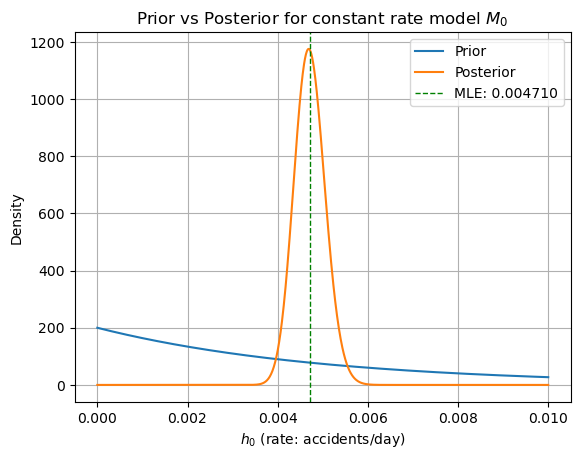

In [7]:
# Grid for plotting
h = np.linspace(0,0.01,1000)

plt.plot(h, prior(h), label="Prior")
plt.plot(h, posterior(h), label="Posterior")
plt.xlabel(r"$h_0$ (rate: accidents/day)")
plt.axvline(N/L, color='g', linestyle='--', linewidth=1, label=f'MLE: {N/L:.6f}')
    
plt.ylabel("Density")
plt.legend()
plt.title(r"Prior vs Posterior for constant rate model $M_0$")
plt.grid(True)
plt.savefig('./figs/constant_rate_model_prior_vs_posterior.pdf')
plt.show()
plt.close()

Calculating the evidence with a direct numerical integration with a shift trick to avoid underflow.

In [ ]:

def log_likelihood(h):
    return N * np.log(h) - L * h

# Peak of the log-likelihood
h_mode = N / L
max_log_like = log_likelihood(h_mode)

# Numerical grid for trapezoidal integration
# We choose a range that captures the peak and decays sufficiently
h_min = 1e-10  # Avoiding log(0)
h_max = h_mode * 5  
num_points = 1000
h_grid = np.linspace(h_min, h_max, num_points)

# Shifted integrand evaluated over the grid
# log_likelihood is vectorized if N and L are scalars
shifted_vals = np.exp(log_likelihood(h_grid) - max_log_like) * prior(h_grid)

# Perform Trapezoidal integration
Z0_shifted = np.trapezoid(shifted_vals, h_grid)

# Add the shift back in the log domain
log_Z0 = np.log(Z0_shifted) + max_log_like

print("log Z0 =", log_Z0)

log Z0 = -1217.0924811139914


In [12]:
log_Z0_analytical = (ALPHA * np.log(BETA) - gammaln(ALPHA) + 
                     gammaln(N + ALPHA) - (N + ALPHA) * np.log(L + BETA))

print(f"Analytical log(Z0): {log_Z0_analytical}")
print(f"Analytical log(Z0) - numerical log(Z0): {log_Z0_analytical - log_Z0}")

Analytical log(Z0): -1217.0924811139917
Analytical log(Z0) - numerical log(Z0): -2.2737367544323206e-13


For this case where we have a conjugate prior and the posterior can be written analytically, We can see that the difference between the analytical and the numerical log eveidences is very small : `-2.2737367544323206e-13`

## Exercise 4 : The 1 change point model, M1.

(a) Use an MCMC package of your choice to sample the posterior for model
𝑀1. Make a corner plot for this posterior. Briefly explain (in under 300 words)
which algorithm/package you used for the MCMC, any important settings for this
algorithm, and any diagnostic checks you performed to check for convergence.

For the 1 change point model $M_1$, we have :

#### 1. Log Prior on $h_0$ and $h_1$
The priors on $h_0$ and $h_1$ are given by $h_j \sim \text{Gamma}(\alpha=1, \beta=200)$ with simplified PDF: $$P(h_j) = 200\exp(-200h_j)$$

#### 2. Log Prior on $s_1$
$s_1$ being distributed as a Dirichlet distribution with shape $\alpha =(2,2) \in \mathbb{R}^2$, we have:
$$\pi(s_1\vert M_1) = \dfrac{1}{L^{2+1}/3!} \times s_1 \times (L-s_1)$$
$$\Rightarrow \log \pi(s_1\vert M_1) = \log s_1 + \log (L-s_1) - \log \left(\dfrac{L^3}{6}\right)$$

#### 3. Likelihood

If $N_0$ is number of accidents before the change point $s_1$ and $N_1 =N - N_0$, we have:


$$\begin{array}{lcl}
\log L &=& \sum_{i=1}^{N} \log\ x (y_i) - \int_0^L dt \ x(t)\\  \\
&=& \sum_{i=1}^{N_0} h_0 + \sum_{i=N_0+1}^{N} h_1 - \int_0^{s_1}dt\ h_0 - \int_{s_1}^{L}dt\ h_1 \\ \\
&=& N_0 h_0 + N_1 h_1 - h_0 s_1 - h_1  (L-s_1)
\end{array}$$

In [13]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_context('paper')

# Constants
ALPHA = 1.0
BETA = 200.0

# Loading accident times
y = np.hstack([0, np.cumsum(intervals)])

N = 191 # len(y)
L = 40550


# Log-likelihood

def log_likelihood(theta):
    """
        Log-likelihood for model M_1.

        Parameters
        ----------
        params : array
            theta = [s1, h0, h1] - change point position and two rates
        """
    s1, h0, h1 = theta

    # Boundary checks
    if s1 <= 0 or s1 >= L or h0 <= 0 or h1 <= 0:
        return -np.inf
    
    # calculating number of accidents before the change point s1
    N0 = np.sum(y < s1)
    N1 = N - N0

    # Log-likelihood
    log_like = N0*np.log(h0) + N1*np.log(h1) - h0*s1-h1*(L-s1)

    return log_like

def log_prior(theta):
    """
    Log-prior for model M_1.

    Parameters
    ----------
    theta : array [s1, h0, h1]
    """

    s1, h0, h1 = theta

    if not (0 < s1 < L and h0 > 0 and h1 > 0):
        return -np.inf
    
    # Gamma(1, 200) distribution PDF on h0 and h1
    log_prior_h0 = ALPHA * np.log(BETA) - gammaln(ALPHA) + (ALPHA - 1) * np.log(h0) - BETA * h0
    log_prior_h1 = ALPHA * np.log(BETA) - gammaln(ALPHA) + (ALPHA - 1) * np.log(h1) - BETA * h1


    # Prior on s1: even-numbered order statistics (k=1)
    log_prior_s1 = np.log(s1) + np.log(L - s1) - np.log(L**3 / 6)

    return log_prior_s1 + log_prior_h0 + log_prior_h1


def log_posterior(theta):
    
    lp = log_prior(theta)
    
    if not np.isfinite(lp):
        return -np.inf
    
    return lp + log_likelihood(theta)

In [14]:
def sample_mcmc_M1(L, N, nwalkers=32, nsteps=10000, burn_in=2000):
    """
    MCMC for model M_1 using emcee.

    Parameters
    ----------
    model : Input Model
        The model instance
    nwalkers : int
        Number of walkers
    nsteps : int
        Number of steps per walker
    burn_in : int
        Number of steps to discard as burn-in
    """
    ndim = 3  # s1, h0, h1

    # Initializing walkers near the middle of the time period 
    # with rates near the mean
    mean_rate = N/L

    pos = np.array([
    np.random.uniform(0.2*L, 0.8*L, nwalkers), # Spread s1 wider
    np.random.uniform(0.5*mean_rate, 1.5*mean_rate, nwalkers), # Diversity in h0
    np.random.uniform(0.5*mean_rate, 1.5*mean_rate, nwalkers)  # Diversity in h1
    ]).T

    # Ensure positive rates
    pos[:, 1:] = np.abs(pos[:, 1:])
    # Ensure s1 in valid range
    pos[:, 0] = np.clip(pos[:, 0], 100, L - 100)


    # Create sampler
    sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior)

    print("Running MCMC for model M_1.")
    print(f"  Number of walkers: {nwalkers}")
    print(f"  Number of steps: {nsteps}")


    sampler.run_mcmc(pos, nsteps, progress=True)

    # Get samples (discard burn-in)
    samples = sampler.get_chain(discard=burn_in, flat=True)

    print(f"  Acceptance fraction: {np.mean(sampler.acceptance_fraction):.3f}")
    print(f"  Number of samples after burn-in: {len(samples)}")

    # Calculate autocorrelation time
    try:
        tau = sampler.get_autocorr_time(discard=burn_in)
        print(f"  Autocorrelation time: {tau}")
    except:
        print("  Could not calculate autocorrelation time")

    return samples, sampler


In [15]:
samples, sampler = sample_mcmc_M1(L, N, nwalkers=32, nsteps=10000, burn_in=2000)

Running MCMC for model M_1.
  Number of walkers: 32
  Number of steps: 10000


100%|██████████| 10000/10000 [00:07<00:00, 1382.14it/s]


  Acceptance fraction: 0.525
  Number of samples after burn-in: 256000
  Autocorrelation time: [46.11529952 51.24388578 45.59330841]


In [16]:
def plot_corner_M1(samples):
    """Create corner plot for M_1 posterior."""
    labels = ['$s_1$ (days)', '$h_0$ (acc/day)', '$h_1$ (acc/day)']

    fig = corner.corner(samples, labels=labels,
                        quantiles=[0.16, 0.5, 0.84],
                        show_titles=True,
                        title_kwargs={"fontsize": 12},
                        title_fmt='.4f')

    
    plt.savefig('./figs/q4a_M1_corner.pdf', dpi=300, bbox_inches='tight')
    plt.tight_layout()
    plt.show()
    plt.close()

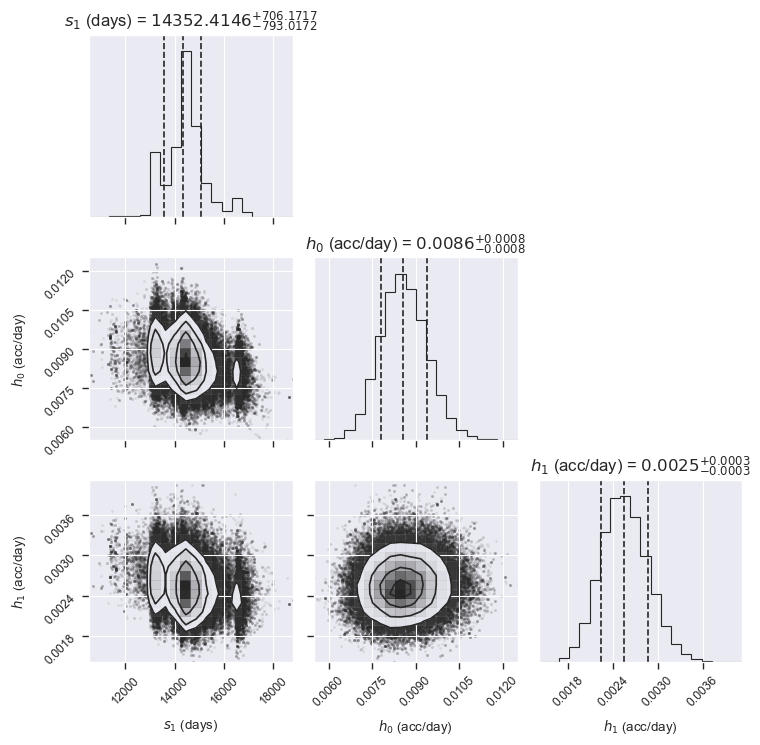

In [17]:
plot_corner_M1(samples)

(b) Explain briefly (in under 200 words) how the Savage Dickey density ratio can,
in principle, be used to find the ratio of evidences between the models 𝑀1 and 𝑀0.
Also explain what difficulty is encountered when trying to use the Savage Dickey
density ratio in this example. You should illustrate your explanation with a plot.

Explanation

In [18]:
s1_samples = samples[:,0]
h0_samples = samples[:,1]
h1_samples = samples[:,2]


def plot_savage_dickey_difficulty(samples):
    """
    Illustrate the difficulty with using Savage Dickey density ratio.

    The Savage Dickey ratio requires evaluating the posterior at a point
    where a nested model is recovered. For M_0 vs M_1, this would be
    when h0 = h1, which defines a surface in the 3D parameter space,
    not a single point.
    """
    # Extract samples
    s1_samples = samples[:, 0]
    h0_samples = samples[:, 1]
    h1_samples = samples[:, 2]

    # Plot h0 vs h1
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # 2D histogram of h0 vs h1
    ax = axes[0]
    h = ax.hist2d(h0_samples, h1_samples, bins=50, cmap='Blues', density=True)
    ax.plot([0, 0.01], [0, 0.01], 'r--', linewidth=2, label='$h_0 = h_1$ (model $M_0$)')
    ax.set_xlabel('$h_0$ (accidents/day)', fontsize=12)
    ax.set_ylabel('$h_1$ (accidents/day)', fontsize=12)
    ax.set_title('Joint posterior of $h_0$ and $h_1$', fontsize=13)
    ax.legend()
    plt.colorbar(h[3], ax=ax, label='Posterior density')

    # Marginal distributions
    ax = axes[1]
    ax.hist(h0_samples, bins=50, alpha=0.5, density=True, label='$h_0$', color='blue')
    ax.hist(h1_samples, bins=50, alpha=0.5, density=True, label='$h_1$', color='red')
    ax.set_xlabel('Rate (accidents/day)', fontsize=12)
    ax.set_ylabel('Posterior density', fontsize=12)
    ax.set_title('Marginal posteriors of $h_0$ and $h_1$', fontsize=13)
    ax.legend()

    plt.tight_layout()
    plt.savefig('./figs/q4b_savage_dickey_difficulty.pdf', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()



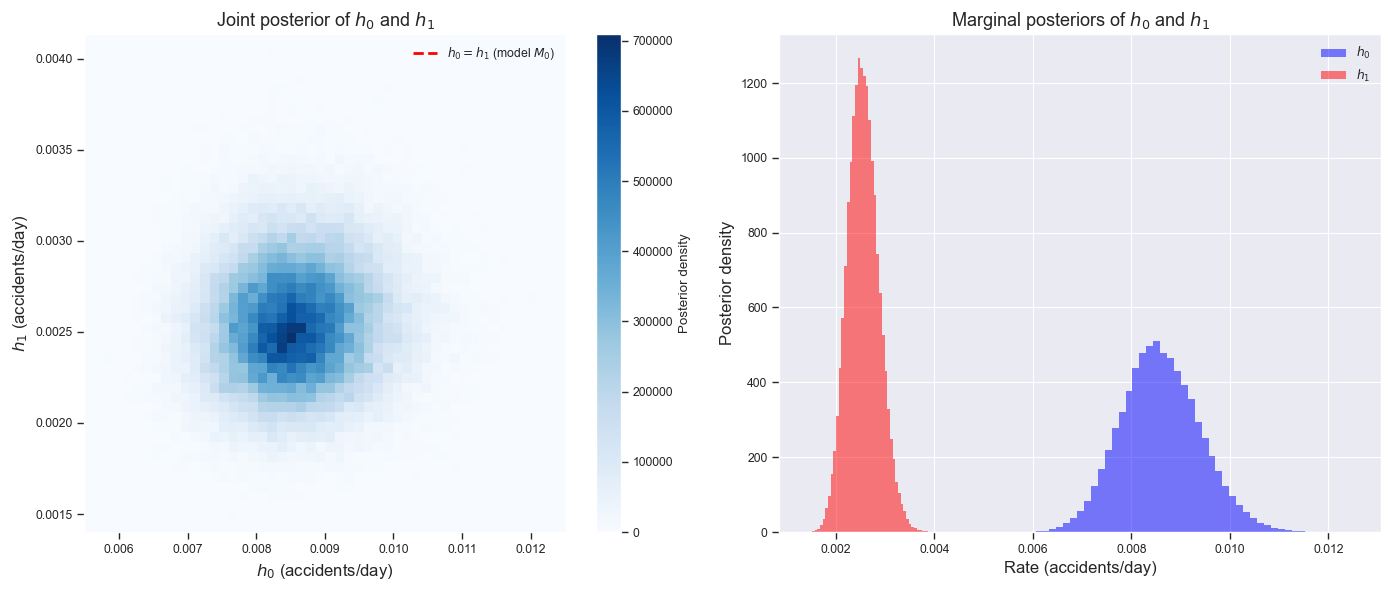

In [19]:
plot_savage_dickey_difficulty(samples)

(d) Use a nested sampling algorithm of your choice to evaluate the evidence for the
model 𝑀1. Using your answer from 3(a), give both the evidence ratio and posterior
odds ratio for the pair of models 𝑀0 and 𝑀1. Describe briefly (in under 200 words)
the details of the algorithm and any relevant settings used.

In [28]:
from scipy.stats import beta

def run_nested_sampling_M1():
    """
    Run nested sampling for model M_1 to calculate the evidence.

    Uses dynesty package.
    """
    ndim = 3  # s1, h0, h1

    def prior_transform(u):
        """Transform unit cube to parameter space."""
        s1 = beta.ppf(u[0], 2, 2) * L
        h0 = gamma.ppf(u[1], a=ALPHA, scale=1.0/BETA) #Gamma prior
        h1 = gamma.ppf(u[2], a=ALPHA, scale=1.0/BETA) #Gamma prior
        return np.array([s1, h0, h1])
    
    def log_likelihood_wrapper(theta):
        """Wrapper for log-likelihood."""
        return log_likelihood(theta)

    # Create nested sampler
    sampler = NestedSampler(log_likelihood_wrapper, prior_transform, ndim,
                           nlive=1000, bound='multi', sample='rwalk')

    # Run nested sampling
    sampler.run_nested(dlogz=0.1, print_progress=True)

    # Get results
    results = sampler.results

    log_Z1 = results.logz[-1]
    log_Z1_err = results.logzerr[-1]

    print(f"\nNested Sampling Results for M_1:")
    print(f"  log(Z1) = {log_Z1:.6f} ± {log_Z1_err:.6f}")
    #print(f"  Evidence Z_1 = {np.exp(log_Z1):.6e}")

    return log_Z1, log_Z1_err, results

In [29]:
log_Z1, log_Z1_err, ns_results = run_nested_sampling_M1()

11467it [00:49, 229.35it/s, +1000 | bound: 9 | nc: 1 | ncall: 218125 | eff(%):  5.742 | loglstar:   -inf < -1178.158 <    inf | logz: -1187.305 +/-  0.085 | dlogz:  0.000 >  0.100]


Nested Sampling Results for M_1:
  log(Z1) = -1187.305114 ± 0.104944


In [30]:
print(f'log_Z0  = {log_Z0}\nlog_Z1  = {log_Z1}')

log_Z0  = -1217.0924811139914
log_Z1  = -1187.3051136559043


In [32]:
def calculate_bayes_factor(log_Z0, log_Z1):
    """Calculate Bayes factor and odds ratio."""
    log_B10 = log_Z1 - log_Z0

    print(f"\nBayes Factor Calculation:")
    print(f"  log(Z_0) = {log_Z0:.6f}")
    print(f"  log(Z_1) = {log_Z1:.6f}")
    print(f"  log(B_10) = log(Z_1/Z_0) = {log_B10:.6f}")
    print(f"  B_10 = Z_1/Z_0 = {np.exp(log_B10):.6e}")

    # Assuming equal prior probabilities for M_0 and M_1
    # Posterior odds = Bayes factor * prior odds
    # If prior odds = 1, then posterior odds = Bayes factor
    print(f"\n  Assuming equal prior probabilities: P(M_0) = P(M_1)")
    print(f"  Posterior odds O_10 = P(M_1|data)/P(M_0|data) = {np.exp(log_B10):.6e}\n")

    if log_B10 > 0:
        print(f"  Model M_1 is preferred over M_0")
    else:
        print(f"  Model M_0 is preferred over M_1")

    return log_B10

In [33]:
_ = calculate_bayes_factor(log_Z0, log_Z1)


Bayes Factor Calculation:
  log(Z_0) = -1217.092481
  log(Z_1) = -1187.305114
  log(B_10) = log(Z_1/Z_0) = 29.787367
  B_10 = Z_1/Z_0 = 8.639514e+12

  Assuming equal prior probabilities: P(M_0) = P(M_1)
  Posterior odds O_10 = P(M_1|data)/P(M_0|data) = 8.639514e+12

  Model M_1 is preferred over M_0


### Exercise 5: The k Change Point Models, $M_k$

(a) Having read and understood the contents of RJMCMC.py, you should complete
the class by implementing the method height_change_move and the expressions
for the log prior ratio in both the birth_move and death_move methods as described
in section 4.3 of Green (1995). Areas where you are required to edit are
marked with a # TO DO: comment in the code

In [34]:
from RJMCMC import RJMCMC

In [35]:
# Creating RJMCMC sampler
sampler = RJMCMC(intervals)

# Running RJMCMC

print("Running Reversible Jump MCMC...")

num_iter = 150000  # Running for 150k iterations
sampler.run_mcmc(num_iter=num_iter)

Running Reversible Jump MCMC...


100%|██████████| 150000/150000 [01:21<00:00, 1834.55it/s]

Height change moves attempted 8.6% of the time with an acceptance fraction of 0.526
Position change moves attempted 8.7% of the time with an acceptance fraction of 0.225
Birth moves attempted 37.9% of the time with an acceptance fraction of 0.269
Death moves attempted 44.9% of the time with an acceptance fraction of 0.227


(b) 

In [36]:
def plot_trace(sampler, burn_in=10000):
    """Plot trace of model index k."""
    chain = sampler.chain

    # Extract k values (number of change points)
    k_values = np.array([(len(x)-1)//2 for x in chain])

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(k_values, 'b-', alpha=0.5, linewidth=0.5)
    ax.axvline(burn_in, color='r', linestyle='--', linewidth=2, label=f'Burn-in: {burn_in}')
    ax.set_xlabel('Iteration', fontsize=12)
    ax.set_ylabel('Number of change points, $k$', fontsize=12)
    ax.set_title('Trace plot for model index $k$', fontsize=14)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('./figs/q5b_trace_k.pdf', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    


def plot_posterior_k(sampler, burn_in=10000):
    """Plot posterior distribution of k."""
    chain = sampler.chain[burn_in:]

    # Extract k values
    k_values = np.array([(len(x)-1)//2 for x in chain])

    # Find MAP
    unique_k, counts = np.unique(k_values, return_counts=True)
    posterior_k = counts / len(k_values)
    k_map = unique_k[np.argmax(posterior_k)]

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(unique_k, posterior_k, width=0.8, alpha=0.7, color='steelblue', edgecolor='black')
    ax.axvline(k_map, color='r', linestyle='--', linewidth=2,
               label=f'MAP: $k = {k_map}$')
    ax.set_xlabel('Number of change points, $k$', fontsize=12)
    ax.set_ylabel('Posterior probability, $P(k|\\{I_i\\})$', fontsize=12)
    ax.set_title('Posterior distribution on model index $k$', fontsize=14)
    ax.legend(fontsize=12)
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.savefig('./figs/q5b_posterior_k.pdf', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

    print(f"\nPosterior distribution of k:")
    for k, p in zip(unique_k, posterior_k):
        print(f"  k = {k:2d}: P(k|data) = {p:.4f}")
    print(f"\nMAP estimate: k = {k_map}")

    return k_map



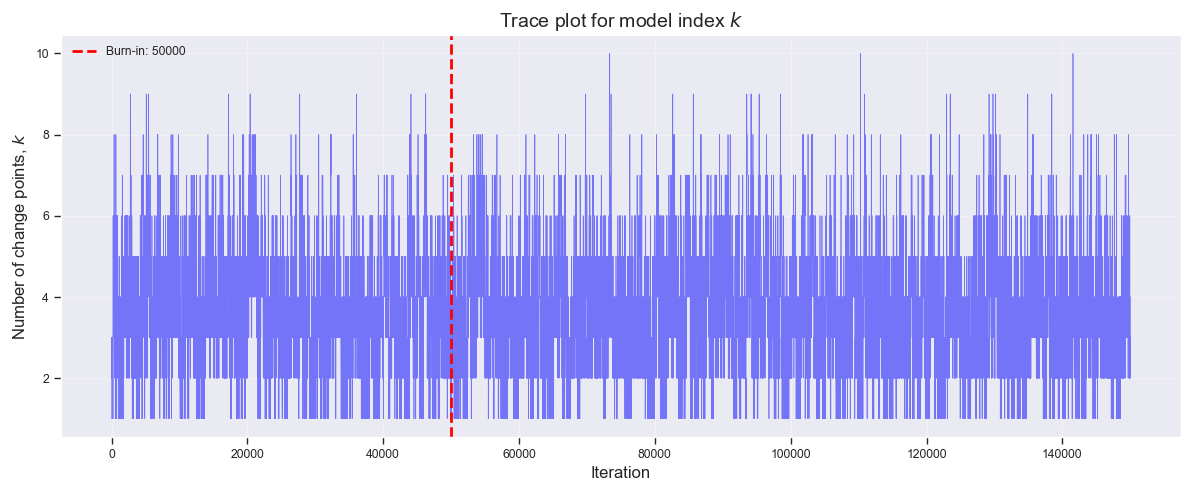

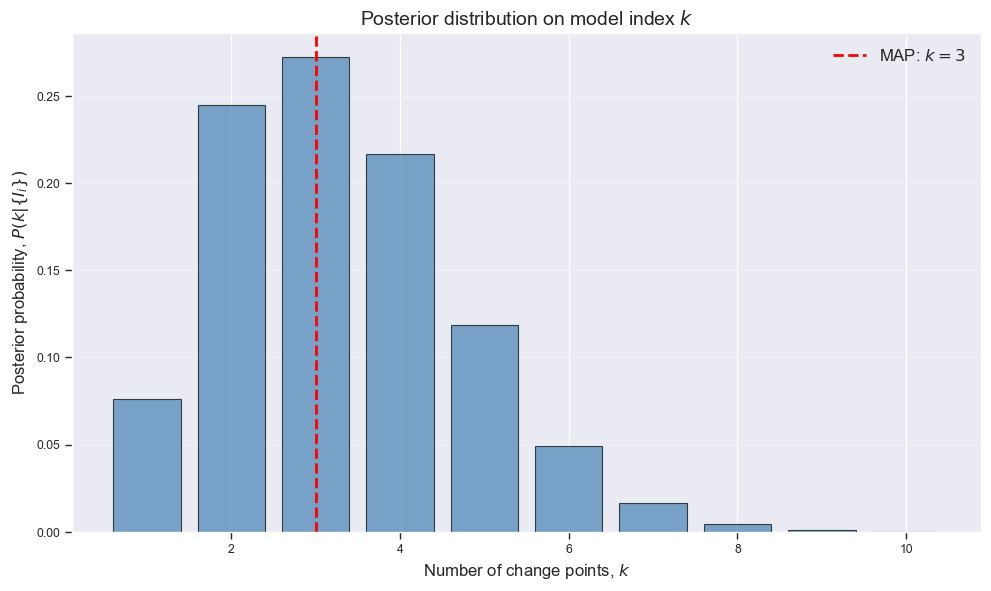


Posterior distribution of k:
  k =  1: P(k|data) = 0.0759
  k =  2: P(k|data) = 0.2450
  k =  3: P(k|data) = 0.2723
  k =  4: P(k|data) = 0.2164
  k =  5: P(k|data) = 0.1187
  k =  6: P(k|data) = 0.0491
  k =  7: P(k|data) = 0.0167
  k =  8: P(k|data) = 0.0048
  k =  9: P(k|data) = 0.0008
  k = 10: P(k|data) = 0.0001

MAP estimate: k = 3


In [37]:

# Plot trace and posterior on k
burn_in = 50000
plot_trace(sampler, burn_in=burn_in)
k_map = plot_posterior_k(sampler, burn_in=burn_in)

(c)

In [38]:
# Plot inferred rate with uncertainties

print("Calculating model-averaged rate x(t).")

def plot_inferred_rate(sampler, burn_in=10000, num_time_points=1000):
    chain = sampler.chain[burn_in:]
    t_grid = np.linspace(0, sampler.duration, num_time_points)
    
    # Vectorized rate extraction across the chain for each grid point
    def get_rates(state, t_grid):
        k = (len(state) - 1) // 2
        idx = np.searchsorted(state[:k], t_grid, side='right')
        return state[k:][idx]

    rates_at_time = np.array([get_rates(s, t_grid) for s in chain]).T
    
    # Calculate percentiles (Median, 50% CI, 90% CI)
    perc = np.percentile(rates_at_time, [5, 25, 50, 75, 95], axis=1)
    t_years = t_grid / 365.25 + 1851 

    fig, ax = plt.subplots(figsize=(14, 7))
    ax.fill_between(t_years, perc[0], perc[4], alpha=0.2, color='blue', label='90% CI')
    ax.fill_between(t_years, perc[1], perc[3], alpha=0.3, color='blue', label='50% CI')
    ax.plot(t_years, perc[2], 'b-', lw=2, label='Median')

    ax.set(xlabel='Year', ylabel='Accident rate (accidents/day)', 
           title='Inferred accident rate $x(t)$ (model-averaged)')
    ax.legend(); ax.grid(True, alpha=0.3)

    # Secondary axis for annual rates
    ax2 = ax.twinx()
    ax2.set_ylabel('Accident rate (accidents/year)')
    ax2.set_ylim(np.array(ax.get_ylim()) * 365.25)

    plt.tight_layout()
    plt.savefig('./figs/q5c_inferred_rate.pdf', dpi=300)
    plt.show()

Calculating model-averaged rate x(t).


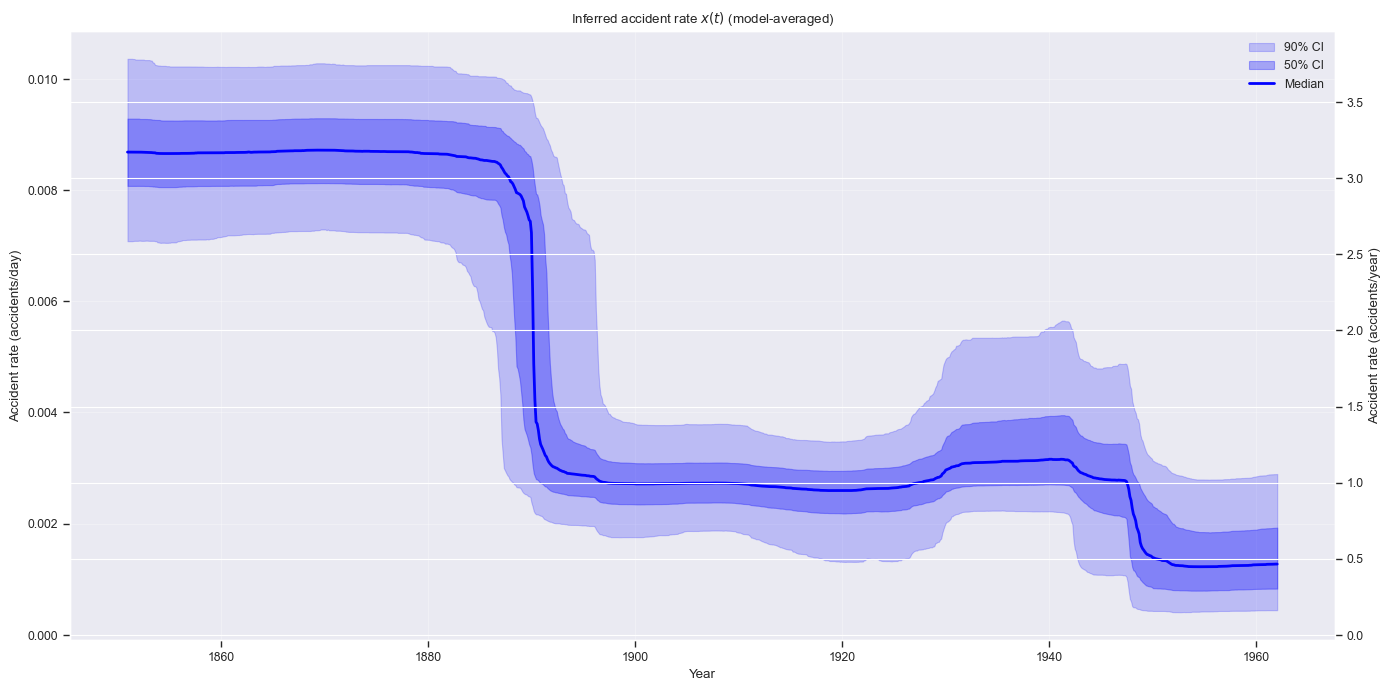

In [39]:

plot_inferred_rate(sampler, burn_in=10000, num_time_points=1000)